# Project 2: Reproducibility in Natural Language Processing



### Read Data

In [21]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-dark') 

In [22]:
from pathlib import Path
outputs_dir = Path('outputs')

In [23]:
sou = pd.read_csv("data/SOTU.csv")
sou

,President,Year,Text,Word Count
0,Joseph R. Biden,2024.0,"\n[Before speaking, the President presented hi...",8003
1,Joseph R. Biden,2023.0,\nThe President. Mr. Speaker——\n[At this point...,8978
2,Joseph R. Biden,2022.0,"\nThe President. Thank you all very, very much...",7539
3,Joseph R. Biden,2021.0,\nThe President. Thank you. Thank you. Thank y...,7734
4,Donald J. Trump,2020.0,\nThe President. Thank you very much. Thank yo...,6169
...,...,...,...,...
241,George Washington,1791.0,\nFellow-Citizens of the Senate and House of R...,2264
242,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
243,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069
244,George Washington,1790.0,\nFellow-Citizens of the Senate and House of R...,1069


### Processing Speeches with SpaCy

In [4]:
!pip install spacy

In [5]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 64.4 MB/s eta 0:00:0000:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [24]:
import spacy
from tqdm import tqdm
from collections import Counter

nlp = spacy.load("en_core_web_sm")

In [25]:
# Subset data frame for 2000 onwards
sou2k = sou[sou["Year"] > 1999]

In [26]:
# Store list of tokens from each speech
token_docs = []

for speech in sou2k["Text"]:
    speech_tokens = nlp(speech)
    token_docs.append(speech_tokens)

### Analyze Tokens vs Lemmas

#### Token List

In [9]:
# List of tokens across all speeches 2000 onwards
tokens = []

for speech in token_docs:
    for token in speech:
        if (token.is_stop==False) & (token.is_punct==False) & (token.is_space==False) & (len(token)>2):
            token = token.lower_
            tokens.append(token)

In [10]:
# Print top 20 tokens
Counter(tokens).most_common(20)

[('america', 816),
 ('people', 637),
 ('american', 582),
 ('new', 530),
 ('years', 439),
 ('americans', 437),
 ('world', 425),
 ('year', 406),
 ('country', 369),
 ('jobs', 348),
 ('tonight', 344),
 ('work', 324),
 ('know', 323),
 ('let', 320),
 ('congress', 317),
 ('nation', 311),
 ('time', 301),
 ('help', 282),
 ('need', 266),
 ('tax', 255)]

#### Lemma List

In [11]:
# List of lemmas
lemmas = []

for speech in token_docs:
    for token in speech:
        if (token.is_stop==False) & (token.is_punct==False) & (token.is_space==False) & (len(token)>2):
            lemma = token.lemma_
            lemmas.append(lemma.lower())

# Print top 20 lemmas
Counter(lemmas).most_common(20)

[('year', 845),
 ('america', 816),
 ('people', 639),
 ('american', 587),
 ('work', 557),
 ('new', 532),
 ('job', 486),
 ('country', 435),
 ('americans', 432),
 ('world', 426),
 ('know', 395),
 ('nation', 388),
 ('help', 378),
 ('need', 353),
 ('time', 351),
 ('tonight', 344),
 ('child', 332),
 ('let', 326),
 ('congress', 317),
 ('come', 301)]

#### Token versus Lemma Comparison

The first thing I notice about the top tokens versus the top lemmas is that they are actually quite similar. This makes sense given that the top tokens would have a direct impact on determining the top lemmas. However, there are some small differences. For instance, our list of tokens includes "year" and "years", which instead is mapped to just "year" in lemmas with its total counts equal to the sum of the two respective tokens. There's also words in our lemma list that are not included in our token list at all, like "child"; this means the tokens that share "child" as their lemma like "child" and "children" don't have enough counts to make our top 20 token list individually, but combined make our top 20 lemma list.

### Common Words

#### Common Words per Year Function

In [12]:
def get_most_common_words(df, year, n=25):
    """
    Processes the SOTU speech for a given year and returns
    the most common non-stopword/punctuation lemmas.
    """

    # Step 1: Subset df
    subset_df = df[df["Year"]==int(year)]

    # Step 2: Process the text with spaCy
    speeches = []
    for speech in subset_df["Text"]:
        speech_tokens = nlp(speech)
        speeches.append(speech_tokens)
    
    # Step 3: Get lemmas
    lemmas = []
    for speech in speeches:
        for token in speech:
            if (token.is_stop==False) & (token.is_punct==False) & (token.is_space==False) & (len(token)>2):
                lemma = token.lemma_
                lemmas.append(lemma.lower())
    top_lemmas = Counter(lemmas).most_common(n)
    
    return top_lemmas

In [13]:
# test function on 2024
get_most_common_words(sou, 2024)

[('president', 58),
 ('year', 45),
 ('america', 44),
 ('american', 34),
 ('people', 33),
 ('member', 32),
 ('want', 29),
 ('audience', 29),
 ('know', 29),
 ('pay', 29),
 ('come', 26),
 ('home', 25),
 ('family', 24),
 ('future', 23),
 ('million', 23),
 ('like', 21),
 ('build', 21),
 ('laughter', 20),
 ('americans', 20),
 ('history', 19),
 ('world', 19),
 ('right', 19),
 ('tax', 19),
 ('house', 18),
 ('tonight', 18)]

#### Comparing 2023 to 2017

In [14]:
words_2023 = get_most_common_words(df=sou, year=2023, n=20)
words_2017 = get_most_common_words(df=sou, year=2017, n=20)

In [15]:
words_2023

[('year', 58),
 ('go', 56),
 ('let', 45),
 ('know', 40),
 ('people', 39),
 ('job', 38),
 ('america', 36),
 ('come', 33),
 ('law', 33),
 ('pay', 33),
 ('american', 31),
 ('president', 30),
 ('look', 27),
 ('world', 25),
 ('folk', 24),
 ('nation', 24),
 ('audience', 23),
 ('work', 23),
 ('right', 23),
 ('member', 22)]

In [16]:
words_2017

[('american', 34),
 ('america', 29),
 ('country', 26),
 ('nation', 21),
 ('great', 20),
 ('new', 19),
 ('year', 19),
 ('world', 18),
 ('job', 15),
 ('people', 15),
 ('americans', 14),
 ('united', 13),
 ('tonight', 13),
 ('states', 12),
 ('work', 12),
 ('child', 12),
 ('want', 12),
 ('time', 12),
 ('citizen', 11),
 ('right', 11)]

In [17]:
df_2017 = pd.DataFrame(words_2017)
df_2017.columns = ["Word", "Count"]
df_2023 = pd.DataFrame(words_2023)
df_2023.columns = ["Word", "Count"]

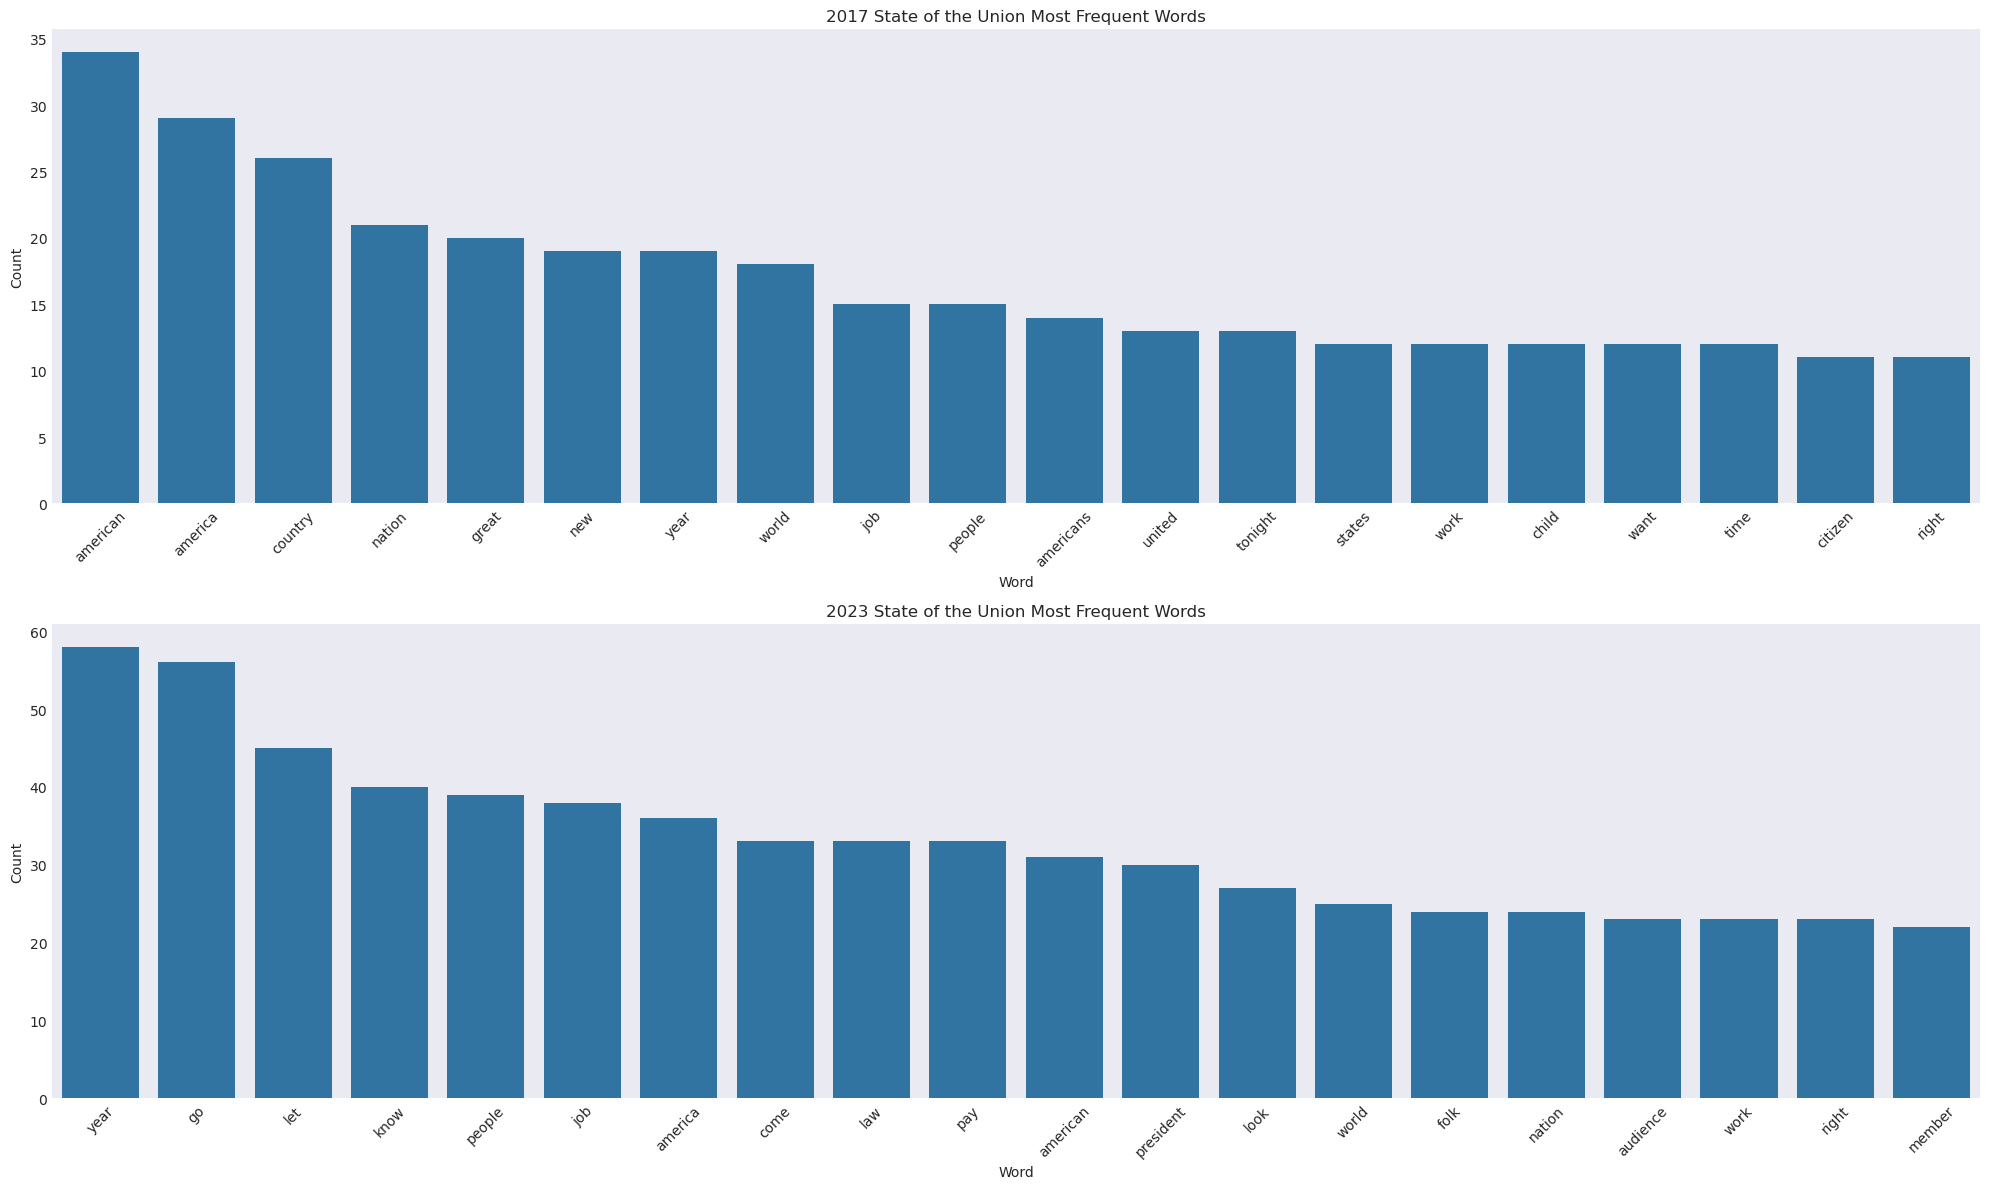

In [27]:
# Bar plots for 2017 and 2023
fig, axes = plt.subplots(2, 1, figsize=(20, 12))

# 2017
sns.barplot(data=df_2017, x="Word", y="Count", ax=axes[0])
axes[0].set_title("2017 State of the Union Most Frequent Words")
axes[0].tick_params(axis="x", rotation=45)

# 2023
sns.barplot(data=df_2023, x="Word", y="Count", ax=axes[1])
axes[1].set_title("2023 State of the Union Most Frequent Words")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(outputs_dir / "2017_2023_sou_frequent_words.png", dpi=300, bbox_inches="tight")
plt.show();

### TF-IDF Vectorization

To use statsitical alorithms on documents, we need to transform them into vectors, where each element of the vector corresponds to a particular word in a document or corpus of documents. One common way is via TF-IDF embeddings. LLMs work similarly - they typically use transformer models to generate text embeddings before sending text through a deep neural network. 

Here we will fit a TF-IDF vectorizer, plot all the speeches on a 2-D grid using PCA and also using a heatmap, and examine TF-IDF scores for the top 10 most common words in the first speech. This is a good resource here: https://medium.com/GeoffreyGordonAshbrook/vector-visualization-2d-plot-your-tf-idf-with-pca-83fa9fccb1d 

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

#### Train the Vectorizer and Transform the Data

In [20]:
# you may use this as input to fit the TF-IDF vectorizer
raw_docs = sou["Text"].to_list()

In [51]:
# Hint - use fit_transform for vectorizer and PCA

The output of `fit_transform()` will be a matrix where each row corresponds to a speech, each column corresponds to a word in the corpus of speeches, and the value is the TF-IDF score which measures the importance of that word in that speech, relative to the rest of the speeches.

#### Plot Speeches

- First used PCA to generate the first chart
- Second use seaborn heatmap with a log-scaled color axis to generate the second chart

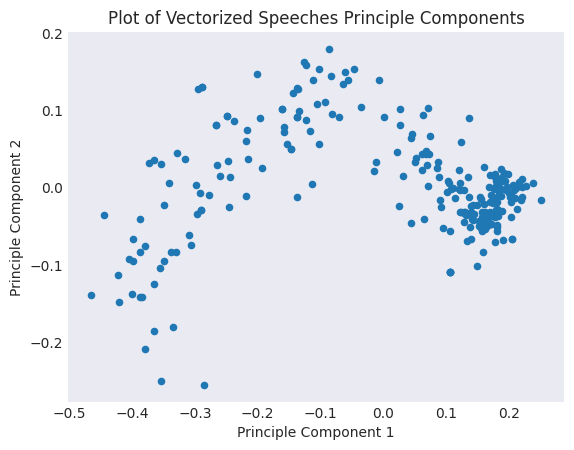

In [52]:
# Step 1: Set PCA to find first 2 principal components

# Step 2: Create a new dataframe where each row is a speech, and each column is a projection onto
# one of the two principal components

# Plot Data Visualization (Matplotlib)

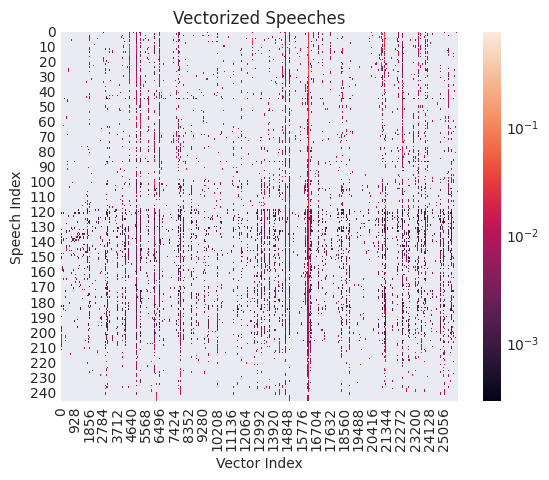

In [53]:
# Hint - vectorized_docs is a sparse matrix whose rows are speeches and columns are tokens, with each
# value being a TF-IDF score. Densify this array first, and then plot using seaborn.

#### Get the TF-IDF value for certain words and documents

In [64]:
word_list = ['year',
 'america',
 'people',
 'american',
 'work',
 'new',
 'job',
 'country',
 'americans',
 'world'] # top ten most common words through whole corpus

In [65]:
word_nums = ... # get each word's index number using the .vocabular_ attributed of vectorizer

In [66]:
idf_score = ... # get their IDF score by using .idf_ at the indices from the previous step

In [67]:
tf_idf = ... # get the tf_idf score for the first speech